# 1 Extracting Data

### 1.0 Imports

In [3]:
import pandas as pd
from fitparse import FitFile
from collections import Counter
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ============================================================
# Parameters
# ============================================================
first_date =  "2026-06-04"

LOCAL_OFFSET = pd.Timedelta(hours=2)

GARMIN_EPOCH = datetime(1989, 12, 31)

# ============================================================
# CHANGE WHEN ADDING NEW DAY
# ============================================================

dates = [
    "2026-06-03",
    "2026-06-04",
    "2026-06-05",
    "2026-06-06",
    "2026-06-07",
    "2026-06-08",
]

COGNITIVE_LOGS = {
    "2026-06-03": [
        ("09:14", "09:59"),
        ("11:00", "11:24"),
        ("11:43", "12:36"),
        ("13:53", "15:11"),
        ("16:17", "17:20"),
    ],
    "2026-06-04": [
        ("10:26", "11:12"),
        ("11:22", "11:30"),
        ("11:38", "12:50"),
        ("14:04", "15:24"),
        ("16:35", "16:57"),
        ("17:25", "17:45"),
        ("17:59", "18:34"),
    ],
    "2026-06-05": [
        ("10:12", "11:48"),
        ("12:22", "12:59"),
        ("14:24", "15:46"),
        ("16:23", "17:39"),
    ],
    "2026-06-06": [
        ("09:42", "10:56"),
        ("11:23", "12:50"),
        ("13:53", "14:49"),
        ("15:55", "17:11"),
    ],
    "2026-06-07": [
        ("16:24", "16:40"),
    ],
    "2026-06-08": [
        ("10:20", "10:42"),
        ("10:55", "12:37"),
        ("13:56", "15:16"),
        ("16:15", "17:05"),
    ],
}

In [5]:
# ============================================================
# Select date and inspect WELLNESS files
# ============================================================
data_dir = Path(f"../data/{first_date}")
wellness_files = sorted(data_dir.glob("*_WELLNESS.fit"))
sleep_file = next(
    data_dir.glob("*_SLEEP_DATA.fit"),
    None
)

print(f"Found {len(wellness_files)} WELLNESS files\n")

summary = []

for file in wellness_files:
    fitfile = FitFile(str(file))

    stress_count = 0

    for _ in fitfile.get_messages("stress_level"):
        stress_count += 1

    summary.append({
        "file": file.name,
        "stress_records": stress_count
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

Found 7 WELLNESS files



,file,stress_records
0,445149236777_WELLNESS.fit,26
1,445278858159_WELLNESS.fit,480
2,445288854395_WELLNESS.fit,31
3,445333908087_WELLNESS.fit,190
4,445394851235_WELLNESS.fit,226
5,445449466445_WELLNESS.fit,234
6,445498126974_WELLNESS.fit,199


### 1.1 Stress

In [7]:
def extract_stress(
    wellness_files,
    curr_date,
    local_offset
):
    """
    Extract stress data from all WELLNESS files for one day.
    """

    all_rows = []

    for file in wellness_files:

        fitfile = FitFile(str(file))

        for msg in fitfile.get_messages("stress_level"):

            row = msg.get_values()

            all_rows.append({
                "source_file": file.name,
                "timestamp": row["stress_level_time"] + local_offset,
                "stress": row["stress_level_value"],
                "body_battery": row.get("body_battery")
            })

    stress_df = pd.DataFrame(all_rows)

    # Garmin missing value
    stress_df["stress"] = (
        stress_df["stress"]
        .replace(-1, pd.NA)
    )

    stress_df = (
        stress_df
        .sort_values("timestamp")
        .drop_duplicates(
            subset="timestamp",
            keep="last"
        )
        .reset_index(drop=True)
    )

    stress_df = stress_df[
        stress_df["timestamp"].dt.date
        == pd.to_datetime(curr_date).date()
    ].copy()

    return stress_df

In [8]:
stress_df = extract_stress(
    wellness_files,
    first_date,
    LOCAL_OFFSET
)

print("Rows:", len(stress_df))
print("Start:", stress_df["timestamp"].min())
print("End:", stress_df["timestamp"].max())

display(stress_df.head())
display(stress_df.tail())

Rows: 1386
Start: 2026-06-04 00:02:00
End: 2026-06-04 23:59:00


,source_file,timestamp,stress,body_battery
0,445149236777_WELLNESS.fit,2026-06-04 00:02:00,17,None
1,445149236777_WELLNESS.fit,2026-06-04 00:03:00,20,None
2,445149236777_WELLNESS.fit,2026-06-04 00:05:00,20,None
3,445149236777_WELLNESS.fit,2026-06-04 00:07:00,25,None
4,445149236777_WELLNESS.fit,2026-06-04 00:08:00,14,None


,source_file,timestamp,stress,body_battery
1381,445498126974_WELLNESS.fit,2026-06-04 23:55:00,15,None
1382,445498126974_WELLNESS.fit,2026-06-04 23:56:00,15,None
1383,445498126974_WELLNESS.fit,2026-06-04 23:57:00,14,None
1384,445498126974_WELLNESS.fit,2026-06-04 23:58:00,14,None
1385,445498126974_WELLNESS.fit,2026-06-04 23:59:00,16,None


### 1.2 Monitor Data

In [10]:
def extract_monitoring(
    wellness_files,
    curr_date
):
    """
    Extract heart-rate monitoring records from Garmin wellness FIT files.
    Reconstruct timestamps from timestamp + timestamp_16.
    """

    rows = []

    for file in wellness_files:

        fitfile = FitFile(str(file))

        last_timestamp = None
        last_timestamp16 = None

        for msg in fitfile.get_messages("monitoring"):

            row = msg.get_values()

            full_ts = row.get("timestamp")
            ts16 = row.get("timestamp_16")
            hr = row.get("heart_rate")

            # Full timestamp anchor
            if full_ts is not None:
                last_timestamp = full_ts + LOCAL_OFFSET

            timestamp = None

            if hr is not None:

                if full_ts is not None:

                    timestamp = full_ts + LOCAL_OFFSET

                elif (
                    ts16 is not None
                    and last_timestamp is not None
                    and last_timestamp16 is not None
                ):

                    delta = ts16 - last_timestamp16

                    # handle 16-bit rollover
                    if delta < 0:
                        delta += 65536

                    timestamp = (
                        last_timestamp
                        + timedelta(seconds=delta)
                    )

                if timestamp is not None:

                    rows.append({
                        "source_file": file.name,
                        "timestamp": timestamp,
                        "heart_rate": hr,
                    })

                    # advance reconstructed timeline
                    last_timestamp = timestamp

            # IMPORTANT:
            # update timestamp16 even when no HR exists
            if ts16 is not None:
                last_timestamp16 = ts16

    monitoring_df = pd.DataFrame(
        rows,
        columns=[
            "source_file",
            "timestamp",
            "heart_rate"
        ]
    )

    if monitoring_df.empty:
        return monitoring_df

    monitoring_df = (
        monitoring_df
        .sort_values("timestamp")
        .drop_duplicates(
            subset="timestamp",
            keep="last"
        )
        .reset_index(drop=True)
    )

    return monitoring_df

In [11]:
monitoring_df = extract_monitoring(
    wellness_files,
    first_date
)

print("Rows:", len(monitoring_df))
print("Start:", monitoring_df["timestamp"].min())
print("End:", monitoring_df["timestamp"].max())

monitoring_df.notna().sum().sort_values(ascending=False)

Rows: 1197
Start: 2026-06-04 00:01:00
End: 2026-06-05 00:00:00


source_file    1197
timestamp      1197
heart_rate     1197
dtype: int64

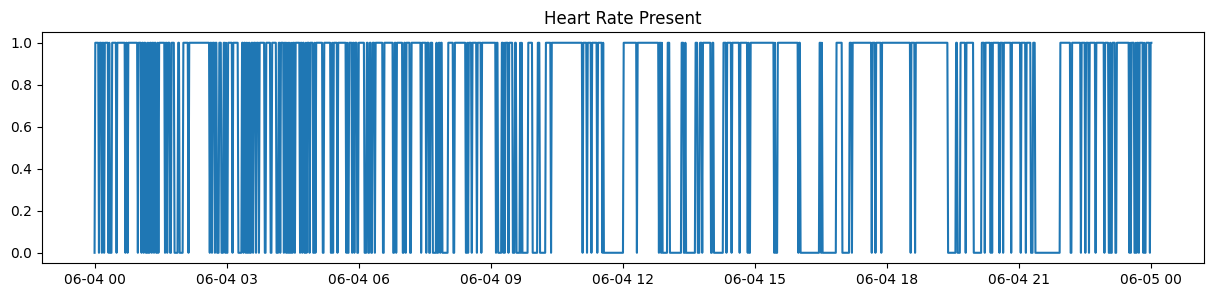

In [12]:
full_day = pd.date_range(
    monitoring_df["timestamp"].min().floor("D"),
    monitoring_df["timestamp"].max().ceil("D"),
    freq="1min"
)

availability = (
    monitoring_df
    .set_index("timestamp")
    .reindex(full_day)
    ["heart_rate"]
    .notna()
)

plt.figure(figsize=(15, 3))
plt.plot(availability.astype(int))
plt.title("Heart Rate Present")
plt.show()

### 1.3 Body Battery

In [14]:
def extract_body_battery(
    wellness_files,
    curr_date,
    local_offset
):
    """
    Extract body battery data from all WELLNESS files for one day.
    """

    all_rows = []

    for file in wellness_files:

        fitfile = FitFile(str(file))

        for msg in fitfile.get_messages("stress_level"):

            row = msg.get_values()

            all_rows.append({
                "source_file": file.name,
                "timestamp": row["stress_level_time"] + local_offset,
                "body_battery": row["unknown_3"]
            })

    body_battery_df = pd.DataFrame(all_rows)

    body_battery_df["body_battery"] = (
        body_battery_df["body_battery"]
        .replace(-1, pd.NA)
    )

    body_battery_df = (
        body_battery_df
        .sort_values("timestamp")
        .drop_duplicates(
            subset="timestamp",
            keep="last"
        )
        .reset_index(drop=True)
    )

    body_battery_df = body_battery_df[
        body_battery_df["timestamp"].dt.date
        == pd.to_datetime(curr_date).date()
    ].copy()

    return body_battery_df

In [15]:
body_battery_df = extract_body_battery(
    wellness_files,
    first_date,
    LOCAL_OFFSET
)

print("Rows:", len(body_battery_df))
print("Start:", body_battery_df["timestamp"].min())
print("End:", body_battery_df["timestamp"].max())

display(body_battery_df.head())
display(body_battery_df.tail())

Rows: 1386
Start: 2026-06-04 00:02:00
End: 2026-06-04 23:59:00


,source_file,timestamp,body_battery
0,445149236777_WELLNESS.fit,2026-06-04 00:02:00,23
1,445149236777_WELLNESS.fit,2026-06-04 00:03:00,23
2,445149236777_WELLNESS.fit,2026-06-04 00:05:00,23
3,445149236777_WELLNESS.fit,2026-06-04 00:07:00,23
4,445149236777_WELLNESS.fit,2026-06-04 00:08:00,23


,source_file,timestamp,body_battery
1381,445498126974_WELLNESS.fit,2026-06-04 23:55:00,26
1382,445498126974_WELLNESS.fit,2026-06-04 23:56:00,26
1383,445498126974_WELLNESS.fit,2026-06-04 23:57:00,26
1384,445498126974_WELLNESS.fit,2026-06-04 23:58:00,26
1385,445498126974_WELLNESS.fit,2026-06-04 23:59:00,26


### 1.4 Respirational Rate

In [17]:
def extract_respiration(
    wellness_files,
    curr_date,
    local_offset,
    garmin_epoch
):
    """
    Extract respiration data from all WELLNESS files for one day.
    """

    all_rows = []

    for file in wellness_files:

        fitfile = FitFile(str(file))

        for msg in fitfile.get_messages("unknown_297"):

            row = msg.get_values()

            all_rows.append({
                "source_file": file.name,
                "timestamp": (
                    garmin_epoch
                    + timedelta(seconds=row["unknown_253"])
                    + local_offset
                ),
                "respiration_rate": row["unknown_0"] / 100
            })

    respiration_df = pd.DataFrame(all_rows)

    respiration_df.loc[
        respiration_df["respiration_rate"] < 0,
        "respiration_rate"
    ] = pd.NA

    respiration_df = (
        respiration_df
        .sort_values("timestamp")
        .drop_duplicates(
            subset="timestamp",
            keep="last"
        )
        .reset_index(drop=True)
    )

    respiration_df = respiration_df[
        respiration_df["timestamp"].dt.date
        == pd.to_datetime(curr_date).date()
    ].copy()

    return respiration_df

In [18]:
respiration_df = extract_respiration(
    wellness_files,
    first_date,
    LOCAL_OFFSET,
    GARMIN_EPOCH
)

print("Rows:", len(respiration_df))
print("Start:", respiration_df["timestamp"].min())
print("End:", respiration_df["timestamp"].max())

display(respiration_df.head())
display(respiration_df.tail())

Rows: 1439
Start: 2026-06-04 00:01:00
End: 2026-06-04 23:59:00


,source_file,timestamp,respiration_rate
0,445149236777_WELLNESS.fit,2026-06-04 00:01:00,15.00
1,445149236777_WELLNESS.fit,2026-06-04 00:02:00,13.66
2,445149236777_WELLNESS.fit,2026-06-04 00:03:00,14.16
3,445149236777_WELLNESS.fit,2026-06-04 00:04:00,15.41
4,445149236777_WELLNESS.fit,2026-06-04 00:05:00,14.16


,source_file,timestamp,respiration_rate
1434,445498126974_WELLNESS.fit,2026-06-04 23:55:00,15.41
1435,445498126974_WELLNESS.fit,2026-06-04 23:56:00,15.33
1436,445498126974_WELLNESS.fit,2026-06-04 23:57:00,15.08
1437,445498126974_WELLNESS.fit,2026-06-04 23:58:00,14.58
1438,445498126974_WELLNESS.fit,2026-06-04 23:59:00,14.41


### 1.5 Event Logs - Activity Type

In [20]:
ACTIVITY_MAP = {
    0: "generic",
    1: "running",
    2: "cycling",
    6: "walking",
    8: "sedentary"
}

In [21]:
def extract_activity_events(
    wellness_files,
    GARMIN_EPOCH,
    LOCAL_OFFSET
):
    """
    Extract Garmin auto-detected activity events.

    Decodes:
        unknown_14 -> activity code
        unknown_15 -> start timestamp

    Returns:
        timestamp
        start_timestamp
        end_timestamp
        activity_code
        activity_type
        duration_min
    """

    ACTIVITY_MAP = {
        0: "generic",
        1: "running",
        2: "cycling",
        6: "walking",
        8: "sedentary"
    }

    rows = []

    for file in wellness_files:

        fitfile = FitFile(str(file))

        for msg in fitfile.get_messages("event"):

            row = msg.get_values()

            # Skip non-auto-activity markers
            if row.get("event") != 54:
                continue

            activity_code = row.get("unknown_14")
            duration_min = row.get("data")
            start_seconds = row.get("unknown_15")

            if (
                activity_code is None
                or duration_min is None
                or start_seconds is None
            ):
                continue

            start_timestamp = (
                GARMIN_EPOCH
                + timedelta(seconds=int(start_seconds))
                + LOCAL_OFFSET
            )

            end_timestamp = (
                start_timestamp
                + timedelta(minutes=int(duration_min))
            )

            rows.append({
                "source_file": file.name,
                "timestamp": row.get("timestamp"),

                "activity_code": activity_code,
                "activity_type": ACTIVITY_MAP.get(
                    activity_code,
                    "unknown"
                ),

                "duration_min": int(duration_min),

                "start_timestamp": start_timestamp,
                "end_timestamp": end_timestamp
            })

    events_df = (
        pd.DataFrame(rows)
        .sort_values("start_timestamp")
        .reset_index(drop=True)
    )

    return events_df

In [22]:
events_df = extract_activity_events(
    wellness_files,
    GARMIN_EPOCH,
    LOCAL_OFFSET
)

print("Rows:", len(events_df))

if len(events_df) > 0:
    print("Start:", events_df["start_timestamp"].min())
    print("End:", events_df["end_timestamp"].max())

display(events_df.head())
display(events_df.tail())

print(events_df["activity_type"].value_counts())

Rows: 241
Start: 2026-06-03 23:31:00
End: 2026-06-04 23:06:00


,source_file,timestamp,activity_code,activity_type,duration_min,start_timestamp,end_timestamp
0,445278858159_WELLNESS.fit,2026-06-03 22:38:00,8,sedentary,52,2026-06-03 23:31:00,2026-06-04 00:23:00
1,445278858159_WELLNESS.fit,2026-06-03 22:39:00,0,generic,1,2026-06-04 00:23:00,2026-06-04 00:24:00
2,445278858159_WELLNESS.fit,2026-06-03 22:44:00,8,sedentary,5,2026-06-04 00:24:00,2026-06-04 00:29:00
3,445278858159_WELLNESS.fit,2026-06-03 22:45:00,0,generic,1,2026-06-04 00:29:00,2026-06-04 00:30:00
4,445278858159_WELLNESS.fit,2026-06-03 22:47:00,8,sedentary,2,2026-06-04 00:30:00,2026-06-04 00:32:00


,source_file,timestamp,activity_code,activity_type,duration_min,start_timestamp,end_timestamp
236,445498126974_WELLNESS.fit,2026-06-04 21:14:00,0,generic,7,2026-06-04 22:52:00,2026-06-04 22:59:00
237,445498126974_WELLNESS.fit,2026-06-04 21:15:00,8,sedentary,1,2026-06-04 22:59:00,2026-06-04 23:00:00
238,445498126974_WELLNESS.fit,2026-06-04 21:16:00,0,generic,1,2026-06-04 23:00:00,2026-06-04 23:01:00
239,445498126974_WELLNESS.fit,2026-06-04 21:20:00,8,sedentary,4,2026-06-04 23:01:00,2026-06-04 23:05:00
240,445498126974_WELLNESS.fit,2026-06-04 21:21:00,0,generic,1,2026-06-04 23:05:00,2026-06-04 23:06:00


activity_type
generic      120
sedentary    111
walking        6
cycling        3
running        1
Name: count, dtype: int64


### 1.6 Sleep Data

In [24]:
def extract_sleep_levels(
    sleep_file,
    LOCAL_OFFSET
):
    """
    Extract sleep stage transitions and sleep
    start/stop times from SLEEP_DATA.fit.
    """

    sleep_map = {
        1: "awake",
        2: "light",
        3: "deep",
        4: "rem"
    }

    all_rows = []

    sleep_start = None
    sleep_stop = None

    fitfile = FitFile(str(sleep_file))

    # ========================================================
    # Sleep start / stop events
    # ========================================================

    for msg in fitfile.get_messages("event"):

        row = msg.get_values()

        if row.get("event") != 74:
            continue

        timestamp = (
            row["timestamp"]
            + LOCAL_OFFSET
        )

        if row.get("event_type") == "start":
            sleep_start = timestamp

        elif row.get("event_type") == "stop":
            sleep_stop = timestamp

    # ========================================================
    # Sleep stage transitions
    # ========================================================

    for msg in fitfile.get_messages("unknown_275"):

        row = msg.get_values()

        stage_code = row.get("unknown_0")
        garmin_epoch = row.get("unknown_253")

        if (
            stage_code is None
            or garmin_epoch is None
        ):
            continue

        timestamp = (
            GARMIN_EPOCH
            + pd.to_timedelta(
                garmin_epoch,
                unit="s"
            )
            + LOCAL_OFFSET
        )

        all_rows.append({
            "timestamp": timestamp,
            "sleep_level": sleep_map.get(
                stage_code,
                "unknown"
            )
        })

    sleep_df = pd.DataFrame(all_rows)

    if not sleep_df.empty:

        sleep_df = (
            sleep_df
            .sort_values("timestamp")
            .drop_duplicates(
                subset="timestamp",
                keep="last"
            )
            .reset_index(drop=True)
        )

    return (
        sleep_df,
        sleep_start,
        sleep_stop
    )

In [25]:
def extract_sleep_score(
    sleep_file
):
    """
    Extract Garmin overall sleep score.
    """

    fit = FitFile(str(sleep_file))

    for msg in fit.get_messages("unknown_346"):

        row = {
            field.name: field.value
            for field in msg
        }

        return row["unknown_6"]

    return np.nan

In [26]:
def extract_sleep_end(
    sleep_file,
    local_offset
):
    """
    Extract sleep end (wake-up) timestamp from Garmin sleep FIT file.

    Returns
    -------
    pd.Timestamp
        Wake-up timestamp rounded up to the next minute
        and adjusted to local time.
    """

    fit = FitFile(str(sleep_file))

    sleep_end = None

    for msg in fit.get_messages("event"):

        row = {
            field.name: field.value
            for field in msg
        }

        if (
            row.get("event") == 74
            and row.get("event_type") == "stop"
        ):
            sleep_end = row["timestamp"]
            break

    if sleep_end is None:
        return pd.NaT
    
    sleep_end = (
        pd.Timestamp(sleep_end)
        + local_offset
    ).ceil("min")
    
    return sleep_end

In [27]:
sleep_score = extract_sleep_score(
    sleep_file
)

print(sleep_score)

80


In [28]:
sleep_end = extract_sleep_end(
    sleep_file,
    LOCAL_OFFSET
)

print(sleep_end)

2026-06-04 08:28:00


In [29]:
sleep_df, sleep_start, sleep_stop = (
    extract_sleep_levels(
        sleep_file,
        LOCAL_OFFSET
    )
)

print("Rows:", len(sleep_df))
print("Sleep start:", sleep_start)
print("Sleep stop :", sleep_stop)

display(sleep_df.head())
display(sleep_df.tail())

Rows: 24
Sleep start: 2026-06-03 23:43:44
Sleep stop : 2026-06-04 08:27:44


,timestamp,sleep_level
0,2026-06-03 23:46:44,light
1,2026-06-04 00:24:44,deep
2,2026-06-04 00:44:44,awake
3,2026-06-04 01:17:44,light
4,2026-06-04 01:26:44,deep


,timestamp,sleep_level
19,2026-06-04 07:14:44,light
20,2026-06-04 07:15:44,awake
21,2026-06-04 07:26:44,light
22,2026-06-04 07:30:44,awake
23,2026-06-04 08:27:44,light


### 1.7 Merging

In [31]:
def build_daily_df(
    stress_df,
    body_battery_df,
    respiration_df,
    monitoring_df,
    sleep_df,
    sleep_start,
    sleep_stop,
    sleep_score,      
    sleep_end,        
    events_df,
    curr_date
):
    """
    Merge all extracted Garmin data into a unified
    1-minute dataframe for one day.

    Activity labels come from events_df.
    Sleep stages come from SLEEP_DATA.fit.
    """

    # ========================================================
    # Ensure datetime dtype
    # ========================================================

    for df in [
        stress_df,
        body_battery_df,
        respiration_df,
        monitoring_df,
        sleep_df,
        events_df
    ]:
        if len(df) > 0:
            for col in df.columns:
                if "timestamp" in col:
                    df[col] = pd.to_datetime(df[col])

    target_date = pd.to_datetime(curr_date).date()

    # ========================================================
    # Filter physiological data
    # ========================================================

    stress_df = stress_df[
        stress_df["timestamp"].dt.date == target_date
    ].copy()

    body_battery_df = body_battery_df[
        body_battery_df["timestamp"].dt.date == target_date
    ].copy()

    respiration_df = respiration_df[
        respiration_df["timestamp"].dt.date == target_date
    ].copy()

    monitoring_df = monitoring_df[
        monitoring_df["timestamp"].dt.date == target_date
    ].copy()

    # ========================================================
    # Full timeline
    # ========================================================

    full_index = pd.date_range(
        start=pd.Timestamp(curr_date),
        periods=1440,
        freq="1min"
    )

    daily_df = pd.DataFrame(index=full_index)

    # ========================================================
    # Helper
    # ========================================================

    def prepare_minute_df(df, value_col):

        if len(df) == 0:
            return pd.DataFrame(columns=[value_col])

        temp = df.copy()

        temp["timestamp"] = (
            temp["timestamp"]
            .dt.floor("min")
        )

        return (
            temp.groupby("timestamp")[value_col]
            .first()
            .to_frame()
        )

    # ========================================================
    # Physiological features
    # ========================================================

    stress_min = prepare_minute_df(
        stress_df,
        "stress"
    )

    body_battery_min = prepare_minute_df(
        body_battery_df,
        "body_battery"
    )

    respiration_min = prepare_minute_df(
        respiration_df,
        "respiration_rate"
    )

    heart_rate_min = prepare_minute_df(
        monitoring_df,
        "heart_rate"
    )

    sleep_min = prepare_minute_df(
        sleep_df,
        "sleep_level"
    )

    # ========================================================
    # Merge physiological features
    # ========================================================

    for feature_df in [
        stress_min,
        body_battery_min,
        respiration_min,
        heart_rate_min
    ]:
        daily_df = daily_df.join(feature_df)

    # ========================================================
    # Sleep stages
    # ========================================================

    daily_df = daily_df.join(
        sleep_min,
        how="left"
    )

    daily_df["sleep_level"] = (
        daily_df["sleep_level"]
        .ffill()
    )

    daily_df["sleep_level"] = (
        daily_df["sleep_level"]
        .fillna("awake")
    )

    # before sleep starts -> awake

    if sleep_start is not None:

        daily_df.loc[
            daily_df.index < sleep_start,
            "sleep_level"
        ] = "awake"

    # after sleep ends -> awake

    if sleep_stop is not None:

        daily_df.loc[
            daily_df.index > sleep_stop,
            "sleep_level"
        ] = "awake"

    # ========================================================
    # Sleep score
    # ========================================================
    
    daily_df["sleep_score"] = np.nan
    
    if (
        sleep_score is not None
        and pd.notna(sleep_end)
    ):
    
        daily_df.loc[
            daily_df.index >= sleep_end,
            "sleep_score"
        ] = sleep_score

    # ========================================================
    # Activity labels
    # ========================================================

    daily_df["activity_type"] = np.nan

    events_day = events_df[
        events_df["start_timestamp"].dt.date
        == target_date
    ].copy()

    for _, event in events_day.iterrows():

        mask = (
            (daily_df.index >= event["start_timestamp"])
            &
            (daily_df.index < event["end_timestamp"])
        )

        daily_df.loc[
            mask,
            "activity_type"
        ] = event["activity_type"]

    # ========================================================
    # Finalize
    # ========================================================

    daily_df.index.name = "timestamp"

    return daily_df.reset_index()

In [32]:
daily_df = build_daily_df(
    stress_df,
    body_battery_df,
    respiration_df,
    monitoring_df,
    sleep_df,
    sleep_start,
    sleep_stop,
    sleep_score,      # NEW
    sleep_end,        # NEW
    events_df,
    first_date
)

print("Shape:", daily_df.shape)

print("\nMissing values:")
print(daily_df.isna().sum())

print("\nDate range:")
print(daily_df["timestamp"].min())
print(daily_df["timestamp"].max())

print("\nSleep score:")
print(sleep_score)

print("\nSleep end:")
print(sleep_end)

display(daily_df.head(20))

Shape: (1440, 8)

Missing values:
timestamp             0
stress              144
body_battery         54
respiration_rate    273
heart_rate          278
sleep_level           0
sleep_score         508
activity_type        77
dtype: int64

Date range:
2026-06-04 00:00:00
2026-06-04 23:59:00

Sleep score:
80

Sleep end:
2026-06-04 08:28:00


C:\Users\gerib\AppData\Local\Temp\ipykernel_30392\1587619562.py:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'generic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  daily_df.loc[


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type
0,2026-06-04 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,NaN
1,2026-06-04 00:01:00,NaN,NaN,15.00,61.0,awake,NaN,NaN
2,2026-06-04 00:02:00,17,23.0,13.66,58.0,awake,NaN,NaN
3,2026-06-04 00:03:00,20,23.0,14.16,60.0,awake,NaN,NaN
4,2026-06-04 00:04:00,NaN,NaN,15.41,58.0,awake,NaN,NaN
5,2026-06-04 00:05:00,20,23.0,14.16,59.0,awake,NaN,NaN
6,2026-06-04 00:06:00,NaN,NaN,13.91,NaN,awake,NaN,NaN
7,2026-06-04 00:07:00,25,23.0,16.54,63.0,awake,NaN,NaN
8,2026-06-04 00:08:00,14,23.0,15.75,56.0,awake,NaN,NaN
9,2026-06-04 00:09:00,17,23.0,14.75,58.0,awake,NaN,NaN


In [33]:
print(
    daily_df[
        ["timestamp", "sleep_score"]
    ]
    .dropna()
    .head(10)
)

              timestamp  sleep_score
508 2026-06-04 08:28:00         80.0
509 2026-06-04 08:29:00         80.0
510 2026-06-04 08:30:00         80.0
511 2026-06-04 08:31:00         80.0
512 2026-06-04 08:32:00         80.0
513 2026-06-04 08:33:00         80.0
514 2026-06-04 08:34:00         80.0
515 2026-06-04 08:35:00         80.0
516 2026-06-04 08:36:00         80.0
517 2026-06-04 08:37:00         80.0


### 1.8 Cognitive Target

In [35]:
def add_cognitive_target(
    daily_df,
    curr_date,
    cognitive_logs
):
    """
    Add binary cognitive target.

    is_cognitive = 1 during logged cognitive sessions
    is_cognitive = 0 otherwise
    """

    daily_df = daily_df.copy()

    daily_df["timestamp"] = pd.to_datetime(
        daily_df["timestamp"]
    )

    daily_df["is_cognitive"] = 0

    sessions = cognitive_logs.get(
        curr_date,
        []
    )

    for start_str, end_str in sessions:

        start_dt = pd.Timestamp(
            f"{curr_date} {start_str}"
        )

        end_dt = pd.Timestamp(
            f"{curr_date} {end_str}"
        )

        mask = (
            (daily_df["timestamp"] >= start_dt)
            &
            (daily_df["timestamp"] < end_dt)
        )

        daily_df.loc[
            mask,
            "is_cognitive"
        ] = 1

    return daily_df

In [36]:
print(daily_df["timestamp"].head())
print(daily_df["timestamp"].tail())

0   2026-06-04 00:00:00
1   2026-06-04 00:01:00
2   2026-06-04 00:02:00
3   2026-06-04 00:03:00
4   2026-06-04 00:04:00
Name: timestamp, dtype: datetime64[ns]
1435   2026-06-04 23:55:00
1436   2026-06-04 23:56:00
1437   2026-06-04 23:57:00
1438   2026-06-04 23:58:00
1439   2026-06-04 23:59:00
Name: timestamp, dtype: datetime64[ns]


In [37]:
daily_df = add_cognitive_target(
    daily_df,
    first_date,
    COGNITIVE_LOGS
)

print(
    daily_df["is_cognitive"]
    .value_counts()
)

is_cognitive
0    1157
1     283
Name: count, dtype: int64


### 1.9 Save Function

In [39]:
def save_full_df(
    full_df,
    output_dir="../final_dfs",
    filename="full_df.csv"
):
    """
    Save the full extracted dataframe as one CSV file.
    """

    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    output_file = output_dir / filename

    full_df.to_csv(
        output_file,
        index=False
    )

    print(f"Saved: {output_file}")

### 1.10 Data Extraction

In [41]:
def extract_day(
    curr_date,
    local_offset,
    garmin_epoch,
    cognitive_logs
):
    """
    Complete extraction pipeline for one day.

    Returns:
        daily_df
    """

    # ========================================================
    # Locate files
    # ========================================================

    data_dir = Path(f"../data/{curr_date}")

    wellness_files = sorted(
        data_dir.glob("*_WELLNESS.fit")
    )

    sleep_file = next(
        data_dir.glob("*_SLEEP_DATA.fit"),
        None
    )

    # ========================================================
    # Wellness-derived features
    # ========================================================

    stress_df = extract_stress(
        wellness_files,
        curr_date,
        local_offset
    )

    body_battery_df = extract_body_battery(
        wellness_files,
        curr_date,
        local_offset
    )

    respiration_df = extract_respiration(
        wellness_files,
        curr_date,
        local_offset,
        garmin_epoch
    )

    monitoring_df = extract_monitoring(
        wellness_files,
        curr_date
    )

    events_df = extract_activity_events(
        wellness_files,
        garmin_epoch,
        local_offset
    )

    # ========================================================
    # Sleep features
    # ========================================================
    
    if sleep_file is not None:
    
        (
            sleep_df,
            sleep_start,
            sleep_stop
        ) = extract_sleep_levels(
            sleep_file,
            local_offset
        )
    
        sleep_score = extract_sleep_score(
            sleep_file
        )
    
        sleep_end = extract_sleep_end(
            sleep_file,
            local_offset
        )
    
    else:
    
        sleep_df = pd.DataFrame(
            columns=[
                "timestamp",
                "sleep_level"
            ]
        )
    
        sleep_start = None
        sleep_stop = None
    
        sleep_score = np.nan
        sleep_end = pd.NaT

    # ========================================================
    # Optional debug
    # ========================================================

    print(
        f"{curr_date} | "
        f"sleep rows={len(sleep_df)} | "
        f"start={sleep_start} | "
        f"stop={sleep_stop} | "
        f"score={sleep_score} | "
        f"end={sleep_end}"
    )

    # ========================================================
    # Build minute-level dataframe
    # ========================================================

    daily_df = build_daily_df(
        stress_df,
        body_battery_df,
        respiration_df,
        monitoring_df,
        sleep_df,
        sleep_start,
        sleep_stop,
        sleep_score,
        sleep_end,
        events_df,
        curr_date
    )

    # ========================================================
    # Add cognitive workload target
    # ========================================================

    daily_df = add_cognitive_target(
        daily_df,
        curr_date,
        cognitive_logs
    )

    return daily_df

### 1.11 Extracting multiple days at once

In [43]:
# ============================================================
# Process all dates into one full dataframe
# ============================================================

daily_dfs = []

for curr_date in dates:

    print(f"\nProcessing {curr_date}")

    day_df = extract_day(
        curr_date,
        LOCAL_OFFSET,
        GARMIN_EPOCH,
        COGNITIVE_LOGS
    )

    daily_dfs.append(day_df)


# ============================================================
# Combine all days
# ============================================================

full_df = pd.concat(
    daily_dfs,
    ignore_index=True
)

# ============================================================
# Save CSV
# ============================================================

save_full_df(
    full_df,
    output_dir="../final_dfs",
    filename="full_df.csv"
)

# ============================================================
# Final checks
# ============================================================

print("\nFull dataframe shape:")
print(full_df.shape)

print("\nFull dataframe missing values:")
print(full_df.isna().sum())

print("\nSleep distribution:")
print(
    full_df["sleep_level"]
    .value_counts(dropna=False)
)

display(full_df.head())
display(full_df.tail())


Processing 2026-06-03
2026-06-03 | sleep rows=18 | start=2026-06-03 01:38:41 | stop=2026-06-03 08:10:41 | score=73 | end=2026-06-03 08:11:00

Processing 2026-06-04


C:\Users\gerib\AppData\Local\Temp\ipykernel_30392\1587619562.py:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'generic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  daily_df.loc[


2026-06-04 | sleep rows=24 | start=2026-06-03 23:43:44 | stop=2026-06-04 08:27:44 | score=80 | end=2026-06-04 08:28:00

Processing 2026-06-05


C:\Users\gerib\AppData\Local\Temp\ipykernel_30392\1587619562.py:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'generic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  daily_df.loc[


2026-06-05 | sleep rows=34 | start=2026-06-04 23:20:58 | stop=2026-06-05 09:08:58 | score=76 | end=2026-06-05 09:09:00

Processing 2026-06-06


...

C:\Users\gerib\AppData\Local\Temp\ipykernel_30392\1587619562.py:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'generic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  daily_df.loc[


2026-06-08 | sleep rows=28 | start=2026-06-07 23:45:41 | stop=2026-06-08 08:47:41 | score=90 | end=2026-06-08 08:48:00
Saved: ..\final_dfs\full_df.csv

Full dataframe shape:
(8640, 9)

Full dataframe missing values:
timestamp              0
stress               936
body_battery         367
respiration_rate    1782
heart_rate          1700
sleep_level            0
sleep_score         3112
activity_type        788
is_cognitive           0
dtype: int64

Sleep distribution:
sleep_level
awake    6700
light     822
deep      574
rem       544
Name: count, dtype: int64


C:\Users\gerib\AppData\Local\Temp\ipykernel_30392\1587619562.py:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'generic' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  daily_df.loc[


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive
0,2026-06-03 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,NaN,0
1,2026-06-03 00:01:00,12,32.0,13.58,NaN,awake,NaN,NaN,0
2,2026-06-03 00:02:00,20,32.0,15.36,64.0,awake,NaN,NaN,0
3,2026-06-03 00:03:00,NaN,NaN,14.91,74.0,awake,NaN,generic,0
4,2026-06-03 00:04:00,22,32.0,16.58,64.0,awake,NaN,sedentary,0


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive
8635,2026-06-08 23:55:00,18,33.0,15.25,NaN,awake,90.0,NaN,0
8636,2026-06-08 23:56:00,21,33.0,14.83,59.0,awake,90.0,NaN,0
8637,2026-06-08 23:57:00,20,33.0,15.16,61.0,awake,90.0,NaN,0
8638,2026-06-08 23:58:00,17,35.0,14.58,58.0,awake,90.0,NaN,0
8639,2026-06-08 23:59:00,19,35.0,15.58,59.0,awake,90.0,NaN,0


# 2 EDA

In [45]:
def check_day(
    full_df,
    check_date
):
    """
    Inspect one day from the final dataframe.
    """

    print("=" * 60)
    print(f"DATE: {check_date}")
    print("=" * 60)

    day_df = full_df[
        full_df["timestamp"].dt.date
        == pd.to_datetime(check_date).date()
    ].copy()

    print("\nShape:")
    print(day_df.shape)

    print("\nMissing values:")
    print(day_df.isna().sum())

    print("\nCognitive distribution:")
    print(
        day_df["is_cognitive"]
        .value_counts(dropna=False)
    )

    print("\nSleep distribution:")
    print(
        day_df["sleep_level"]
        .value_counts(dropna=False)
    )

    display(day_df.head())
    display(day_df.tail())

    return day_df

In [46]:
all_dates = (
    full_df["timestamp"]
    .dt.date
    .astype(str)
    .unique()
)

for curr_date in all_dates:

    check_day(
        full_df,
        curr_date
    )

DATE: 2026-06-03

Shape:
(1440, 9)

Missing values:
timestamp             0
stress              221
body_battery         80
respiration_rate    307
heart_rate          264
sleep_level           0
sleep_score         491
activity_type        32
is_cognitive          0
dtype: int64

Cognitive distribution:
is_cognitive
0    1177
1     263
Name: count, dtype: int64

Sleep distribution:
sleep_level
awake    1185
light      95
rem        82
deep       78
Name: count, dtype: int64


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive
0,2026-06-03 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,NaN,0
1,2026-06-03 00:01:00,12,32.0,13.58,NaN,awake,NaN,NaN,0
2,2026-06-03 00:02:00,20,32.0,15.36,64.0,awake,NaN,NaN,0
3,2026-06-03 00:03:00,NaN,NaN,14.91,74.0,awake,NaN,generic,0
4,2026-06-03 00:04:00,22,32.0,16.58,64.0,awake,NaN,sedentary,0


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive
1435,2026-06-03 23:55:00,17,21.0,14.91,NaN,awake,73.0,NaN,0
1436,2026-06-03 23:56:00,15,21.0,15.25,60.0,awake,73.0,NaN,0
1437,2026-06-03 23:57:00,13,23.0,15.00,59.0,awake,73.0,NaN,0
1438,2026-06-03 23:58:00,17,23.0,14.33,NaN,awake,73.0,NaN,0
1439,2026-06-03 23:59:00,24,23.0,15.16,58.0,awake,73.0,NaN,0


DATE: 2026-06-04

Shape:
(1440, 9)

Missing values:
timestamp             0
stress              144
body_battery         54
respiration_rate    273
heart_rate          278
sleep_level           0
sleep_score         508
activity_type        77
is_cognitive          0
dtype: int64

Cognitive distribution:
is_cognitive
0    1157
1     283
Name: count, dtype: int64

Sleep distribution:
sleep_level
awake    1120
light     137
deep      129
rem        54
Name: count, dtype: int64


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive
1440,2026-06-04 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,NaN,0
1441,2026-06-04 00:01:00,NaN,NaN,15.00,61.0,awake,NaN,NaN,0
1442,2026-06-04 00:02:00,17,23.0,13.66,58.0,awake,NaN,NaN,0
1443,2026-06-04 00:03:00,20,23.0,14.16,60.0,awake,NaN,NaN,0
1444,2026-06-04 00:04:00,NaN,NaN,15.41,58.0,awake,NaN,NaN,0


...

,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive
5760,2026-06-07 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,NaN,0
5761,2026-06-07 00:01:00,NaN,NaN,14.08,NaN,awake,NaN,NaN,0
5762,2026-06-07 00:02:00,15,37.0,14.50,NaN,awake,NaN,NaN,0
5763,2026-06-07 00:03:00,16,38.0,15.25,57.0,awake,NaN,NaN,0
5764,2026-06-07 00:04:00,15,38.0,15.16,NaN,awake,NaN,NaN,0


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive
7195,2026-06-07 23:55:00,5,30.0,14.83,NaN,awake,80.0,NaN,0
7196,2026-06-07 23:56:00,4,30.0,14.50,52.0,awake,80.0,NaN,0
7197,2026-06-07 23:57:00,6,30.0,14.83,NaN,awake,80.0,NaN,0
7198,2026-06-07 23:58:00,6,30.0,14.75,53.0,awake,80.0,NaN,0
7199,2026-06-07 23:59:00,7,30.0,15.33,NaN,awake,80.0,NaN,0


DATE: 2026-06-08

Shape:
(1440, 9)

Missing values:
timestamp             0
stress               94
body_battery          1
respiration_rate    305
heart_rate          285
sleep_level           0
sleep_score         528
activity_type       239
is_cognitive          0
dtype: int64

Cognitive distribution:
is_cognitive
0    1186
1     254
Name: count, dtype: int64

Sleep distribution:
sleep_level
awake    1062
light     179
rem       140
deep       59
Name: count, dtype: int64


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive
7200,2026-06-08 00:00:00,NaN,NaN,NaN,NaN,awake,NaN,NaN,0
7201,2026-06-08 00:01:00,8,30.0,14.75,NaN,awake,NaN,NaN,0
7202,2026-06-08 00:02:00,8,30.0,15.00,NaN,awake,NaN,NaN,0
7203,2026-06-08 00:03:00,7,31.0,15.00,NaN,awake,NaN,NaN,0
7204,2026-06-08 00:04:00,9,31.0,15.25,NaN,awake,NaN,NaN,0


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive
8635,2026-06-08 23:55:00,18,33.0,15.25,NaN,awake,90.0,NaN,0
8636,2026-06-08 23:56:00,21,33.0,14.83,59.0,awake,90.0,NaN,0
8637,2026-06-08 23:57:00,20,33.0,15.16,61.0,awake,90.0,NaN,0
8638,2026-06-08 23:58:00,17,35.0,14.58,58.0,awake,90.0,NaN,0
8639,2026-06-08 23:59:00,19,35.0,15.58,59.0,awake,90.0,NaN,0


# 3 Preprocessing

### 3.1 Missing Values